In [6]:
!pip install -q ultralytics roboflow opencv-python matplotlib pandas pyyaml

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 65.2 MB/s eta 0:00:00


In [7]:
import os
import cv2
import yaml
import shutil
import random
from glob import glob
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ultralytics import YOLO

print("successfully imported")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
successfully imported


In [8]:
!pip install roboflow

from roboflow import Roboflow

rf = Roboflow(api_key="zGO2oHWPQgPnkcoFnRun")
project = rf.workspace("tu-wien-pfowz").project("traffic-sign-detection-yolov8")
version = project.version(9)
dataset = version.download("yolov8")

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to traffic-sign-detection-yolov8-9 in yolov8:: 100%|██████████| 3068/3068 [00:00<00:00, 5233.46it/s]


In [9]:
dataset_path = Path(dataset.location)
print("Dataset location:", dataset_path)

yaml_files = list(dataset_path.glob("*.yaml"))
print("YAML files found:", yaml_files)

DATA_YAML = str(yaml_files[0])
print("Using YAML:", DATA_YAML)

Dataset location: /content/traffic-sign-detection-yolov8-9
YAML files found: [PosixPath('/content/traffic-sign-detection-yolov8-9/data.yaml')]
Using YAML: /content/traffic-sign-detection-yolov8-9/data.yaml


In [10]:
with open(DATA_YAML, "r") as f:
    data_cfg = yaml.safe_load(f)

data_cfg

{'names': ['traffic-signs'],
 'nc': 1,
 'roboflow': {'license': 'MIT',
  'project': 'traffic-sign-detection-yolov8',
  'url': 'https://universe.roboflow.com/tu-wien-pfowz/traffic-sign-detection-yolov8/dataset/9',
  'version': 9,
  'workspace': 'tu-wien-pfowz'},
 'test': '../test/images',
 'train': '../train/images',
 'val': '../valid/images'}

In [11]:
for split in ["train", "val", "test"]:
    if split in data_cfg:
        split_path = Path(data_cfg[split])
        if not split_path.is_absolute():
            data_cfg[split] = str((dataset_path / split_path).resolve())

fixed_yaml_path = dataset_path / "data_fixed.yaml"
with open(fixed_yaml_path, "w") as f:
    yaml.dump(data_cfg, f)

DATA_YAML = str(fixed_yaml_path)
print("Fixed YAML saved at:", DATA_YAML)
print(data_cfg)

Fixed YAML saved at: /content/traffic-sign-detection-yolov8-9/data_fixed.yaml
{'names': ['traffic-signs'], 'nc': 1, 'roboflow': {'license': 'MIT', 'project': 'traffic-sign-detection-yolov8', 'url': 'https://universe.roboflow.com/tu-wien-pfowz/traffic-sign-detection-yolov8/dataset/9', 'version': 9, 'workspace': 'tu-wien-pfowz'}, 'test': '/content/test/images', 'train': '/content/train/images', 'val': '/content/valid/images'}


In [12]:
def count_images(folder):
    folder = Path(folder)
    count = 0
    for ext in ["*.jpg", "*.jpeg", "*.png"]:
        count += len(list(folder.glob(ext)))
    return count

print("Train images:", count_images(data_cfg["train"]))
print("Val images:", count_images(data_cfg["val"]))
print("Test images:", count_images(data_cfg["test"]))

Train images: 0
Val images: 0
Test images: 0


In [13]:
from pathlib import Path

dataset_path = Path(dataset.location)

for p in dataset_path.iterdir():
    print(p)

/content/traffic-sign-detection-yolov8-9/valid
/content/traffic-sign-detection-yolov8-9/README.dataset.txt
/content/traffic-sign-detection-yolov8-9/data.yaml
/content/traffic-sign-detection-yolov8-9/test
/content/traffic-sign-detection-yolov8-9/data_fixed.yaml
/content/traffic-sign-detection-yolov8-9/README.roboflow.txt
/content/traffic-sign-detection-yolov8-9/train


In [14]:
train_dir = dataset_path / "train"

for p in train_dir.iterdir():
    print(p)

/content/traffic-sign-detection-yolov8-9/train/labels
/content/traffic-sign-detection-yolov8-9/train/images


In [15]:
data_cfg["train"] = str(dataset_path / "train" / "images")
data_cfg["val"]   = str(dataset_path / "valid" / "images")
data_cfg["test"]  = str(dataset_path / "test" / "images")

print(data_cfg["train"])
print(data_cfg["val"])
print(data_cfg["test"])

/content/traffic-sign-detection-yolov8-9/train/images
/content/traffic-sign-detection-yolov8-9/valid/images
/content/traffic-sign-detection-yolov8-9/test/images


In [16]:
def count_images(folder):
    folder = Path(folder)
    count = 0
    for ext in ["*.jpg", "*.jpeg", "*.png"]:
        count += len(list(folder.glob(ext)))
    return count

print("Train images:", count_images(data_cfg["train"]))
print("Val images:", count_images(data_cfg["val"]))
print("Test images:", count_images(data_cfg["test"]))

Train images: 1182
Val images: 196
Test images: 150


In [17]:
fixed_yaml_path = dataset_path / "data_fixed.yaml"

with open(fixed_yaml_path, "w") as f:
    yaml.dump(data_cfg, f)

DATA_YAML = str(fixed_yaml_path)

print("Using YAML:", DATA_YAML)

Using YAML: /content/traffic-sign-detection-yolov8-9/data_fixed.yaml


In [18]:
baseline_model = YOLO("yolov8n.pt")
print("YOLOv8n pretrained model loaded")

YOLOv8n pretrained model loaded


In [19]:
baseline_metrics = baseline_model.val(
    data=DATA_YAML,
    split="test",
    imgsz=640,
    conf=0.25,
    iou=0.50,
    project="runs_assignment3",
    name="baseline_eval"
)

print("Baseline Results")
print("mAP50:", baseline_metrics.box.map50)
print("mAP50-95:", baseline_metrics.box.map)
print("Precision:", baseline_metrics.box.mp)
print("Recall:", baseline_metrics.box.mr)

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLOv8n summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1425.3±571.6 MB/s, size: 53.0 KB)
val: Scanning /content/traffic-sign-detection-yolov8-9/test/labels... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 1.2Kit/s 0.1s
val: New cache created: /content/traffic-sign-detection-yolov8-9/test/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 3.0it/s 3.3s
                   all        150        218     0.0281    0.00459     0.0105     0.0021
                person        150        218     0.0281    0.00459     0.0105     0.0021
Speed: 2.3ms preprocess, 4.4ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /content/runs/detect/runs_assignment3/baseline_eval
Baseline Results
mAP50: 0.010507081865004065
mAP50-95: 0.0021014

In [20]:
baseline_model.predict(
    source=data_cfg["test"],
    imgsz=640,
    conf=0.25,
    iou=0.50,
    save=True,
    project="runs_assignment3",
    name="baseline_predictions",
    exist_ok=True
)

print("Baseline predictions saved")


image 1/150 /content/traffic-sign-detection-yolov8-9/test/images/00217_jpg.rf.ba5ade3eafba67712065486fecb5483c.jpg: 480x640 10 cars, 43.2ms
image 2/150 /content/traffic-sign-detection-yolov8-9/test/images/00318_jpg.rf.bcdd29521712c84a2ace989c390bda35.jpg: 480x640 (no detections), 6.5ms
image 3/150 /content/traffic-sign-detection-yolov8-9/test/images/00355_jpg.rf.c1a2f426e05f952833b0f544ed8f8cc8.jpg: 480x640 4 cars, 2 trucks, 8.9ms
image 4/150 /content/traffic-sign-detection-yolov8-9/test/images/00362_jpg.rf.f0ae1e0ae6a86b49c5cfa765557e9116.jpg: 480x640 5 cars, 2 trucks, 6.7ms
image 5/150 /content/traffic-sign-detection-yolov8-9/test/images/00367_jpg.rf.c0aa01d8979c786385c3f1ddbb62fc2f.jpg: 480x640 4 cars, 9.4ms
image 6/150 /content/traffic-sign-detection-yolov8-9/test/images/00370_jpg.rf.ae5066be5aaadd4efb41aa4073565fb8.jpg: 480x640 4 cars, 9.2ms
image 7/150 /content/traffic-sign-detection-yolov8-9/test/images/00378_jpg.rf.990ec0282b922ae6870409b3eadcf3a6.jpg: 480x640 4 cars, 8.5ms
im

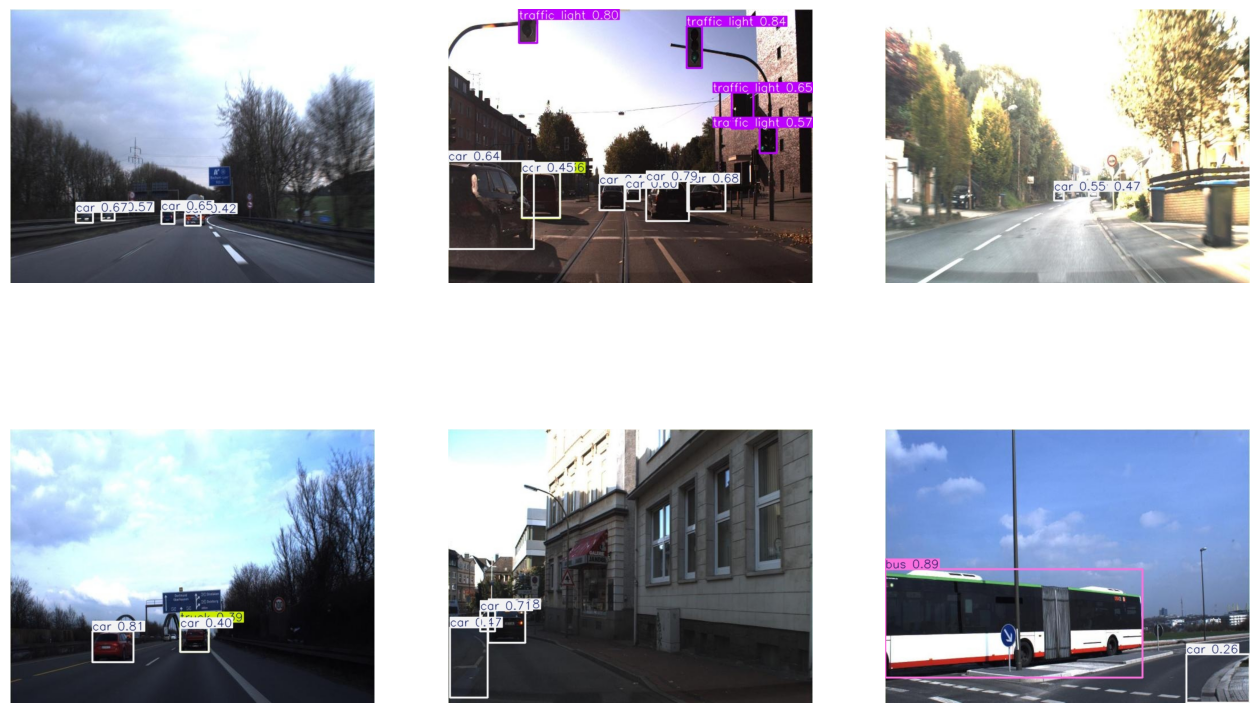

In [21]:
import glob
import cv2
import matplotlib.pyplot as plt

pred_dir = "/content/runs/detect/runs_assignment3/baseline_predictions"

images = glob.glob(pred_dir + "/*.jpg")

plt.figure(figsize=(16,10))

for i, img_path in enumerate(images[:6]):

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.axis("off")

plt.show()

In [22]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

train_results = model.train(
    data=DATA_YAML,
    epochs=30,
    imgsz=1280,
    batch=8,
    patience=10,
    workers=2,
    project="runs_assignment3",
    name="finetuned_yolov8n",
    exist_ok=True
)

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/traffic-sign-detection-yolov8-9/data_fixed.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1280, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=finetuned_yolov8n, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overla

In [23]:
from ultralytics import YOLO

best_weights = "/content/runs/detect/runs_assignment3/finetuned_yolov8n/weights/best.pt"
finetuned_model = YOLO(best_weights)

print("Loaded best model:", best_weights)

Loaded best model: /content/runs/detect/runs_assignment3/finetuned_yolov8n/weights/best.pt


In [24]:
finetuned_test_metrics = finetuned_model.val(
    data=DATA_YAML,
    split="test",
    imgsz=1280,
    conf=0.25,
    iou=0.50,
    project="runs_assignment3",
    name="finetuned_test_eval",
    exist_ok=True
)

print("Fine-tuned TEST Results")
print("mAP50:", finetuned_test_metrics.box.map50)
print("mAP50-95:", finetuned_test_metrics.box.map)
print("Precision:", finetuned_test_metrics.box.mp)
print("Recall:", finetuned_test_metrics.box.mr)

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,005,843 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1254.8±590.5 MB/s, size: 38.3 KB)
val: Scanning /content/traffic-sign-detection-yolov8-9/test/labels.cache... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 48.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.4it/s 7.0s
                   all        150        218      0.913      0.958      0.968      0.677
Speed: 15.9ms preprocess, 10.9ms inference, 0.1ms loss, 3.0ms postprocess per image
Results saved to /content/runs/detect/runs_assignment3/finetuned_test_eval
Fine-tuned TEST Results
mAP50: 0.9683455325144291
mAP50-95: 0.6765030612696552
Precision: 0.9125778595456042
Recall: 0.957686973072268


In [25]:
finetuned_model.predict(
    source=data_cfg["test"],
    imgsz=1280,
    conf=0.25,
    iou=0.50,
    save=True,
    project="runs_assignment3",
    name="finetuned_predictions",
    exist_ok=True
)

print("Fine-tuned predictions saved")


image 1/150 /content/traffic-sign-detection-yolov8-9/test/images/00217_jpg.rf.ba5ade3eafba67712065486fecb5483c.jpg: 960x1280 1 traffic-signs, 38.4ms
image 2/150 /content/traffic-sign-detection-yolov8-9/test/images/00318_jpg.rf.bcdd29521712c84a2ace989c390bda35.jpg: 960x1280 2 traffic-signss, 14.9ms
image 3/150 /content/traffic-sign-detection-yolov8-9/test/images/00355_jpg.rf.c1a2f426e05f952833b0f544ed8f8cc8.jpg: 960x1280 1 traffic-signs, 14.9ms
image 4/150 /content/traffic-sign-detection-yolov8-9/test/images/00362_jpg.rf.f0ae1e0ae6a86b49c5cfa765557e9116.jpg: 960x1280 2 traffic-signss, 14.8ms
image 5/150 /content/traffic-sign-detection-yolov8-9/test/images/00367_jpg.rf.c0aa01d8979c786385c3f1ddbb62fc2f.jpg: 960x1280 4 traffic-signss, 14.8ms
image 6/150 /content/traffic-sign-detection-yolov8-9/test/images/00370_jpg.rf.ae5066be5aaadd4efb41aa4073565fb8.jpg: 960x1280 4 traffic-signss, 14.8ms
image 7/150 /content/traffic-sign-detection-yolov8-9/test/images/00378_jpg.rf.990ec0282b922ae6870409b

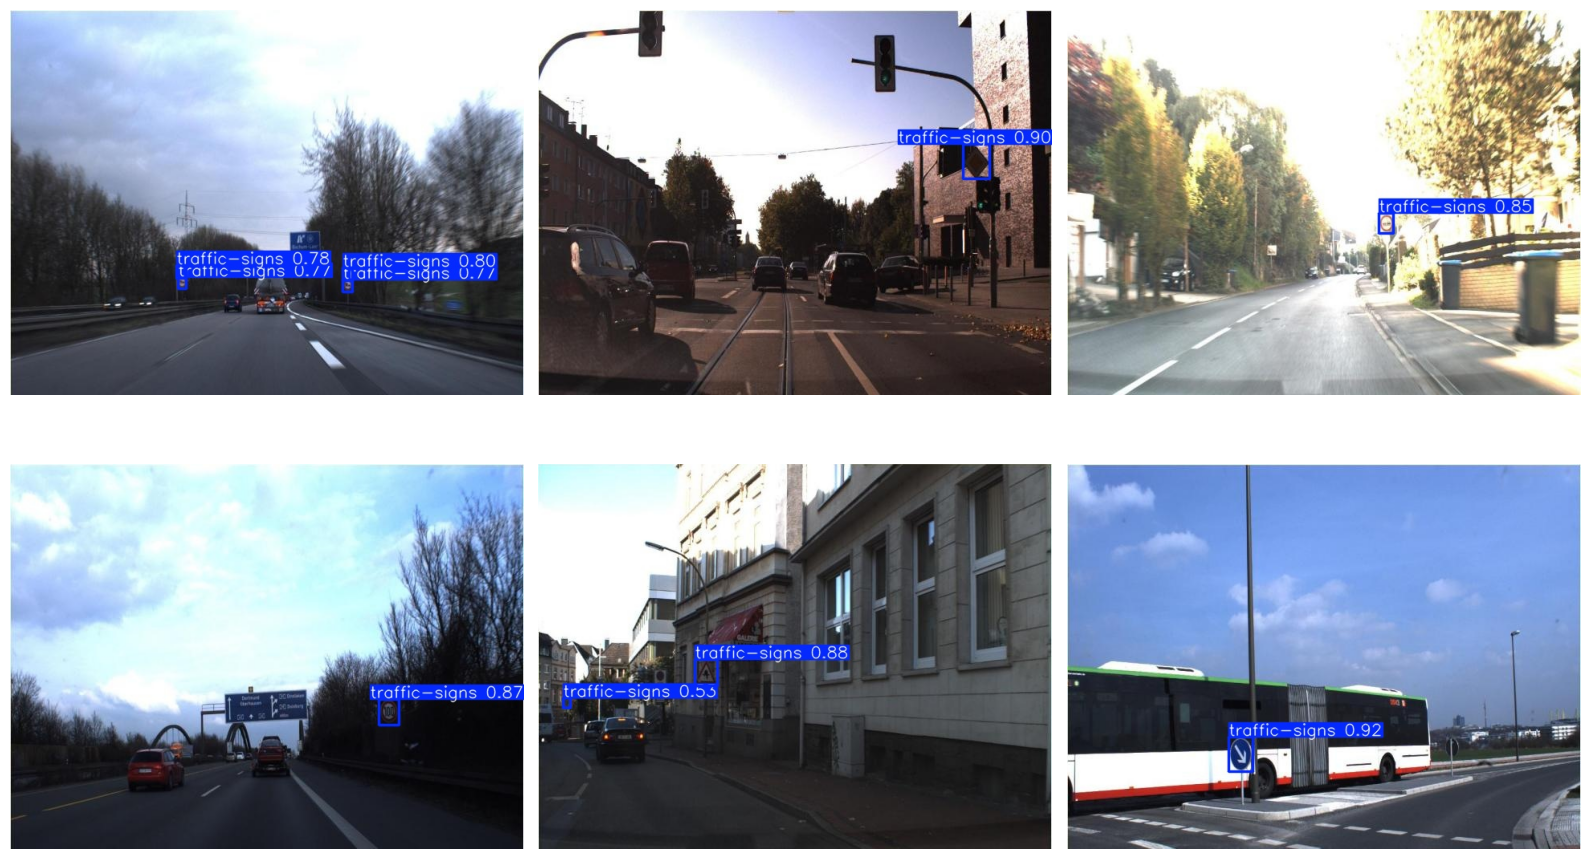

In [26]:
import glob
import cv2
import matplotlib.pyplot as plt

pred_dir = "/content/runs/detect/runs_assignment3/finetuned_predictions"
images = glob.glob(pred_dir + "/*.jpg")

plt.figure(figsize=(16,10))

for i, img_path in enumerate(images[:6]):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
import pandas as pd

comparison_df = pd.DataFrame([
    {
        "Model": "Pretrained YOLOv8n",
        "Image Size": 640,
        "mAP50": float(baseline_metrics.box.map50),
        "mAP50-95": float(baseline_metrics.box.map),
        "Precision": float(baseline_metrics.box.mp),
        "Recall": float(baseline_metrics.box.mr)
    },
    {
        "Model": "Fine-tuned YOLOv8n",
        "Image Size": 1280,
        "mAP50": float(finetuned_test_metrics.box.map50),
        "mAP50-95": float(finetuned_test_metrics.box.map),
        "Precision": float(finetuned_test_metrics.box.mp),
        "Recall": float(finetuned_test_metrics.box.mr)
    }
])

comparison_df

,Model,Image Size,mAP50,mAP50-95,Precision,Recall
0,Pretrained YOLOv8n,640,0.010507,0.002101,0.028113,0.004587
1,Fine-tuned YOLOv8n,1280,0.968346,0.676503,0.912578,0.957687


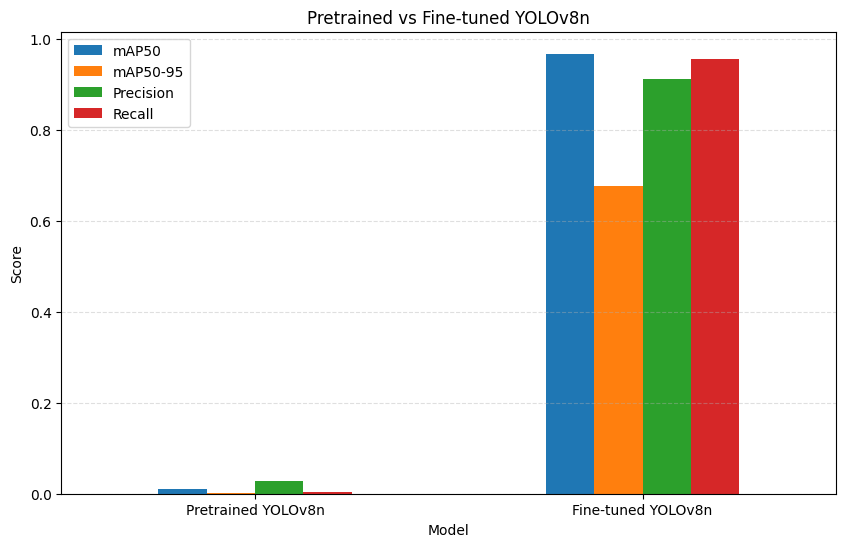

In [28]:
comparison_df.set_index("Model")[["mAP50", "mAP50-95", "Precision", "Recall"]].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Pretrained vs Fine-tuned YOLOv8n")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.show()

In [29]:
rows = []

for conf, iou in [(0.15, 0.45), (0.25, 0.50), (0.35, 0.60)]:
    metrics = finetuned_model.val(
        data=DATA_YAML,
        split="test",
        imgsz=1280,
        conf=conf,
        iou=iou,
        verbose=False
    )

    rows.append({
        "confidence": conf,
        "nms_iou": iou,
        "mAP50": float(metrics.box.map50),
        "mAP50-95": float(metrics.box.map),
        "Precision": float(metrics.box.mp),
        "Recall": float(metrics.box.mr)
    })

tuning_df = pd.DataFrame(rows)
tuning_df

Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1150.3±480.0 MB/s, size: 45.8 KB)
val: Scanning /content/traffic-sign-detection-yolov8-9/test/labels.cache... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 44.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 10/10 1.7it/s 5.9s
                   all        150        218      0.913      0.958       0.97      0.677
Speed: 10.5ms preprocess, 10.7ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to /content/runs/detect/val
Ultralytics 8.4.22 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1278.9±835.8 MB/s, size: 43.0 KB)
val: Scanning /content/traffic-sign-detection-yolov8-9/test/labels.cache... 150 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 150/150 69.9Mit/s 0.0s
              

,confidence,nms_iou,mAP50,mAP50-95,Precision,Recall
0,0.15,0.45,0.969755,0.676688,0.912578,0.957687
1,0.25,0.50,0.968346,0.676503,0.912578,0.957687
2,0.35,0.60,0.962415,0.673419,0.912566,0.957542


In [30]:
comparison_df.to_csv("/content/runs/detect/runs_assignment3/model_comparison.csv", index=False)
tuning_df.to_csv("/content/runs/detect/runs_assignment3/confidence_nms_results.csv", index=False)

print("Saved comparison and tuning CSV files")

Saved comparison and tuning CSV files


The pretrained YOLOv8n model performed poorly on the traffic sign dataset, with very low precision, recall, and mAP values. After fine-tuning the model for 30 epochs using a higher image resolution of 1280, the performance improved significantly. The fine-tuned model achieved an mAP50 of 0.9683, precision of 0.9126, and recall of 0.9577 on the test set. This shows that training the model on the dataset and using a larger image size helped detect small traffic signs more effectively. The best result from the confidence and NMS experiment was obtained with a confidence threshold of 0.15 and IoU of 0.45.